# Cloud satellite estimation

In [1]:
%load_ext autoreload
%autoreload 1
%aimport goesclouds
import os
import goesclouds as gc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

gc.configure_notebook_logging()

In [2]:
window_size = gc.DEFAULT_WINDOW_SIZE
bands = (gc.DEFAULT_BAND, gc.CORRECTION_BAND, 6)

In [3]:
quarter_reports  = gc.load_quarter_reports()
sample_quarters  = gc.select_sample_quarters(quarter_reports)

## Configure cache

Set to `None` to not use the cache.

In [4]:
sample_quarter_cache = 'sample_goes.h5'
missing_quarter_cache = 'missing_goes.h5'
window_sizes_to_cache = [4, 6, 8, 10]
bands_to_cache = bands

## Create cache of samples

In [5]:
def sample_goes_key(band, window_size=gc.DEFAULT_WINDOW_SIZE):
    return f'sample_band_{band}_window_{window_size}'

def cache_samples(band):
    for window_size in window_sizes_to_cache:
        key = sample_goes_key(band, window_size)
        if os.path.isfile(sample_quarter_cache):
            with pd.HDFStore(sample_quarter_cache, mode="r") as store:
                if key in store:
                    print(key, " already cached")
                    continue
        these_samples = gc.extract_band_samples(sample_quarters, band=band, window_size=window_size)
        these_samples.to_hdf(sample_quarter_cache, key=key)
        print("Cached ", key)
        del these_samples

for band in bands:
    cache_samples(band)

sample_band_4_window_4  already cached
sample_band_4_window_6  already cached
sample_band_4_window_8  already cached
sample_band_4_window_10  already cached
sample_band_2_window_4  already cached
sample_band_2_window_6  already cached
sample_band_2_window_8  already cached
sample_band_2_window_10  already cached
sample_band_6_window_4  already cached
sample_band_6_window_6  already cached
sample_band_6_window_8  already cached
sample_band_6_window_10  already cached


## Load and GOES-13 data for years with missing CTIO data

In [6]:
def missing_goes_key(year, band, window_size=gc.DEFAULT_WINDOW_SIZE):
    return f'missing_{year}_band_{band}_window_{window_size}'

def cache_missing_year(quarter_reports, year):
    missing_quarters = gc.select_missing_quarters(quarter_reports, year=year)

    for band in (2, 4):
        for window_size in window_sizes_to_cache:
            key = missing_goes_key(year, band, window_size)
            try:
                with pd.HDFStore(missing_quarter_cache, mode="r") as store:
                    if key in store:
                        print(key, " already cached")
                        continue
            except FileNotFoundError:
                pass
            these_samples = gc.extract_band_samples(missing_quarters, band=band, window_size=window_size)
            these_samples.to_hdf(missing_quarter_cache, key=key)
            del these_samples
            print("Cached ", key)

for year in np.arange(2012, 2018):
    cache_missing_year(quarter_reports, year)

missing_2012_band_2_window_4  already cached
missing_2012_band_2_window_6  already cached
missing_2012_band_2_window_8  already cached
missing_2012_band_2_window_10  already cached
missing_2012_band_4_window_4  already cached
missing_2012_band_4_window_6  already cached
missing_2012_band_4_window_8  already cached
missing_2012_band_4_window_10  already cached
missing_2013_band_2_window_4  already cached
missing_2013_band_2_window_6  already cached
missing_2013_band_2_window_8  already cached
missing_2013_band_2_window_10  already cached
missing_2013_band_4_window_4  already cached
missing_2013_band_4_window_6  already cached
missing_2013_band_4_window_8  already cached
missing_2013_band_4_window_10  already cached
missing_2014_band_2_window_4  already cached
missing_2014_band_2_window_6  already cached
missing_2014_band_2_window_8  already cached
missing_2014_band_2_window_10  already cached
missing_2014_band_4_window_4  already cached
missing_2014_band_4_window_6  already cached
missi

## Get quarters of interest

In [7]:
missing_year = 2015
missing_quarters = gc.select_missing_quarters(quarter_reports, year=missing_year)

## Single-band analysis

Pixel samples for one band, summary stats, and the per-quarter
brightness-based cloud-eighths estimate.

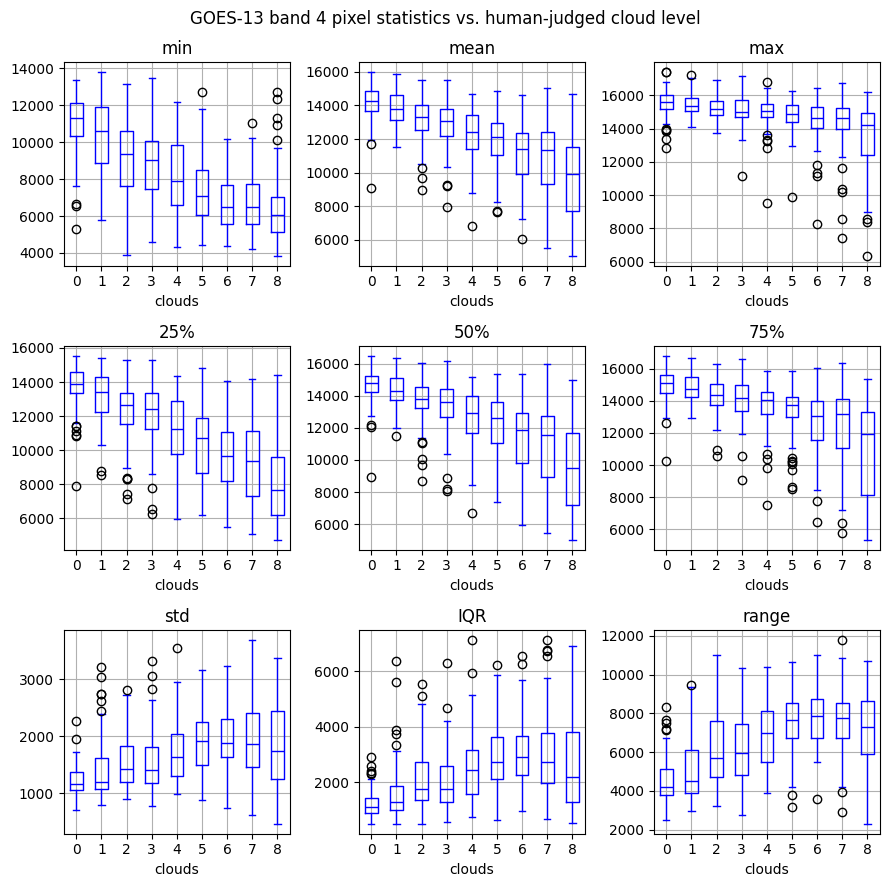

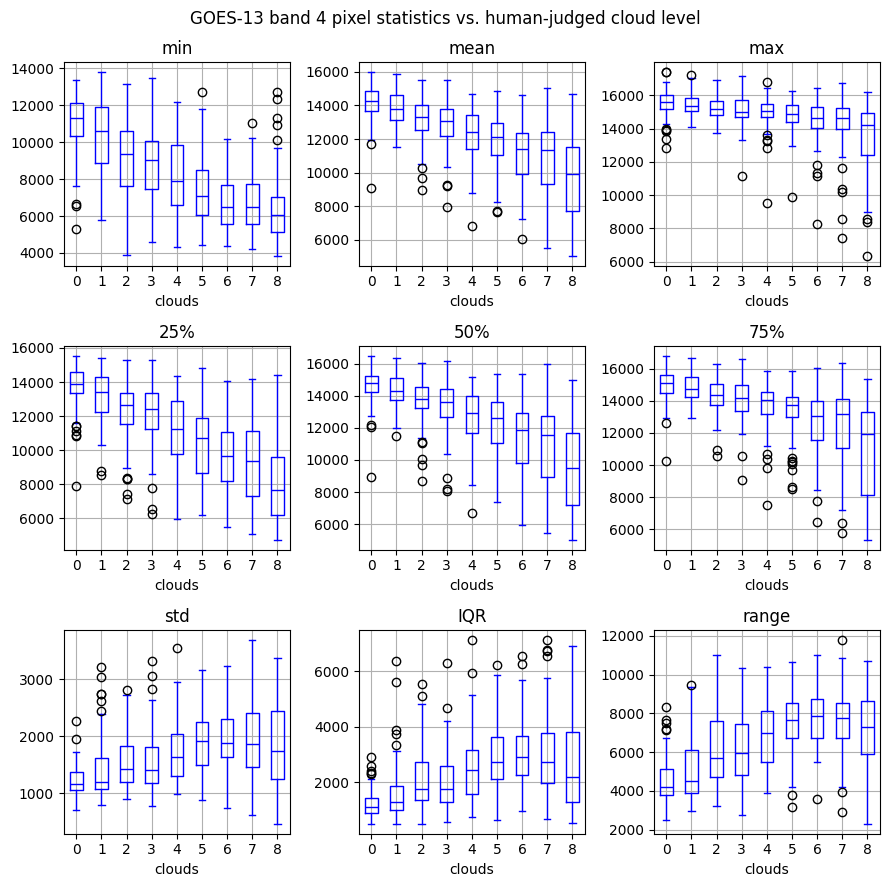

In [8]:
band = 4
if sample_quarter_cache is None or not os.path.isfile(sample_quarter_cache):
    band_samples = gc.extract_band_samples(sample_quarters, band=band)
else:
    key = sample_goes_key(band)
    band_samples = pd.read_hdf(sample_quarter_cache, key)

stats = gc.compute_sample_stats(band_samples)
gc.plot_sample_stats(stats, band=band)

13312

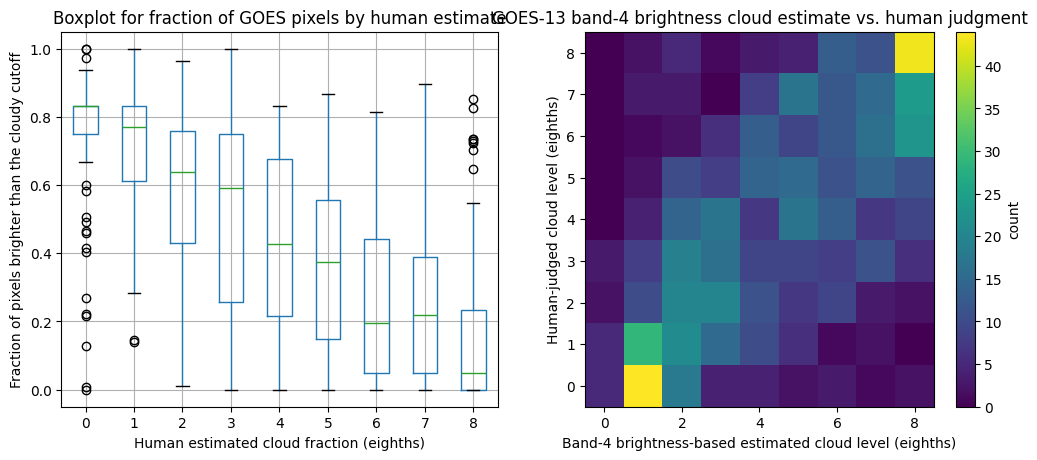

In [9]:
#cloudcut   = gc.reference_quantile(band_samples, f"band{band}")
cloudcut   = gc.optimize_cloudcut_obs(band_samples, f"band{band}")
by_quarter = gc.compute_by_quarter(band_samples, f"band{band}", cloudcut)
gc.plot_by_quarter(by_quarter, band=band)
cloudcut

## Fill missing quarters, one band

`cloudcut` comes from the calibration sample and is reused, unchanged, for
the 2015 quarters with a missing human report.

PosixPath('satellite_clouds_band4_2015.txt')

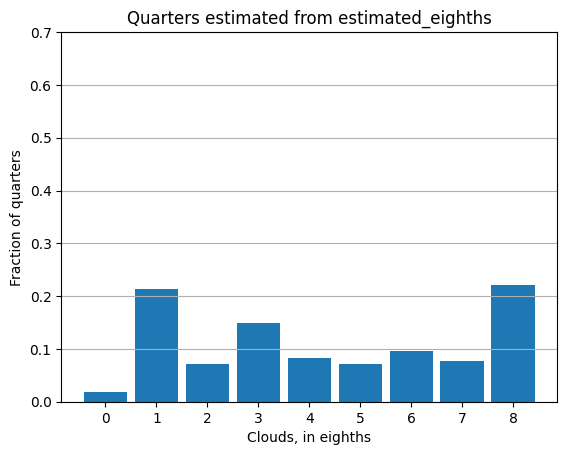

In [10]:
if missing_quarter_cache is None:
    missing_samples = gc.extract_band_samples(missing_quarters, band=band)
else:
    key = missing_goes_key(missing_year, band)
    missing_samples = pd.read_hdf(missing_quarter_cache, key)

missing_by_quarter = gc.compute_by_quarter(missing_samples, f"band{band}", cloudcut)
gc.plot_estimate_histogram(missing_by_quarter)
gc.write_band_estimates(missing_by_quarter, f"satellite_clouds_band{band}_2015.txt")

## Multi-band comparison

Join bands 2, 4, and 6 into one pixel-indexed frame, then build the
`(band, stat)`-columned `sample_stats` frame as per-band
`compute_sample_stats` + `pd.concat` (there is no
`compute_sample_stats_multiband` -- see `goesclouds.md` §7.4).

In [11]:
multiband = gc.load_multiband_samples(sample_quarters, bands=(2, 4, 6))

human_clouds = None
band_stat_frames = {}
for b in (2, 4, 6):
    band_values = gc.as_value_frame(multiband, (b, "value"))
    s = gc.compute_sample_stats(band_values, value_column="value")
    human_clouds = s["clouds"]
    del s["clouds"]
    s.columns = pd.MultiIndex.from_product([[b], s.columns])
    band_stat_frames[b] = s
multiband_stats = pd.concat(band_stat_frames.values(), axis=1)
multiband_stats[("human", "clouds")] = human_clouds

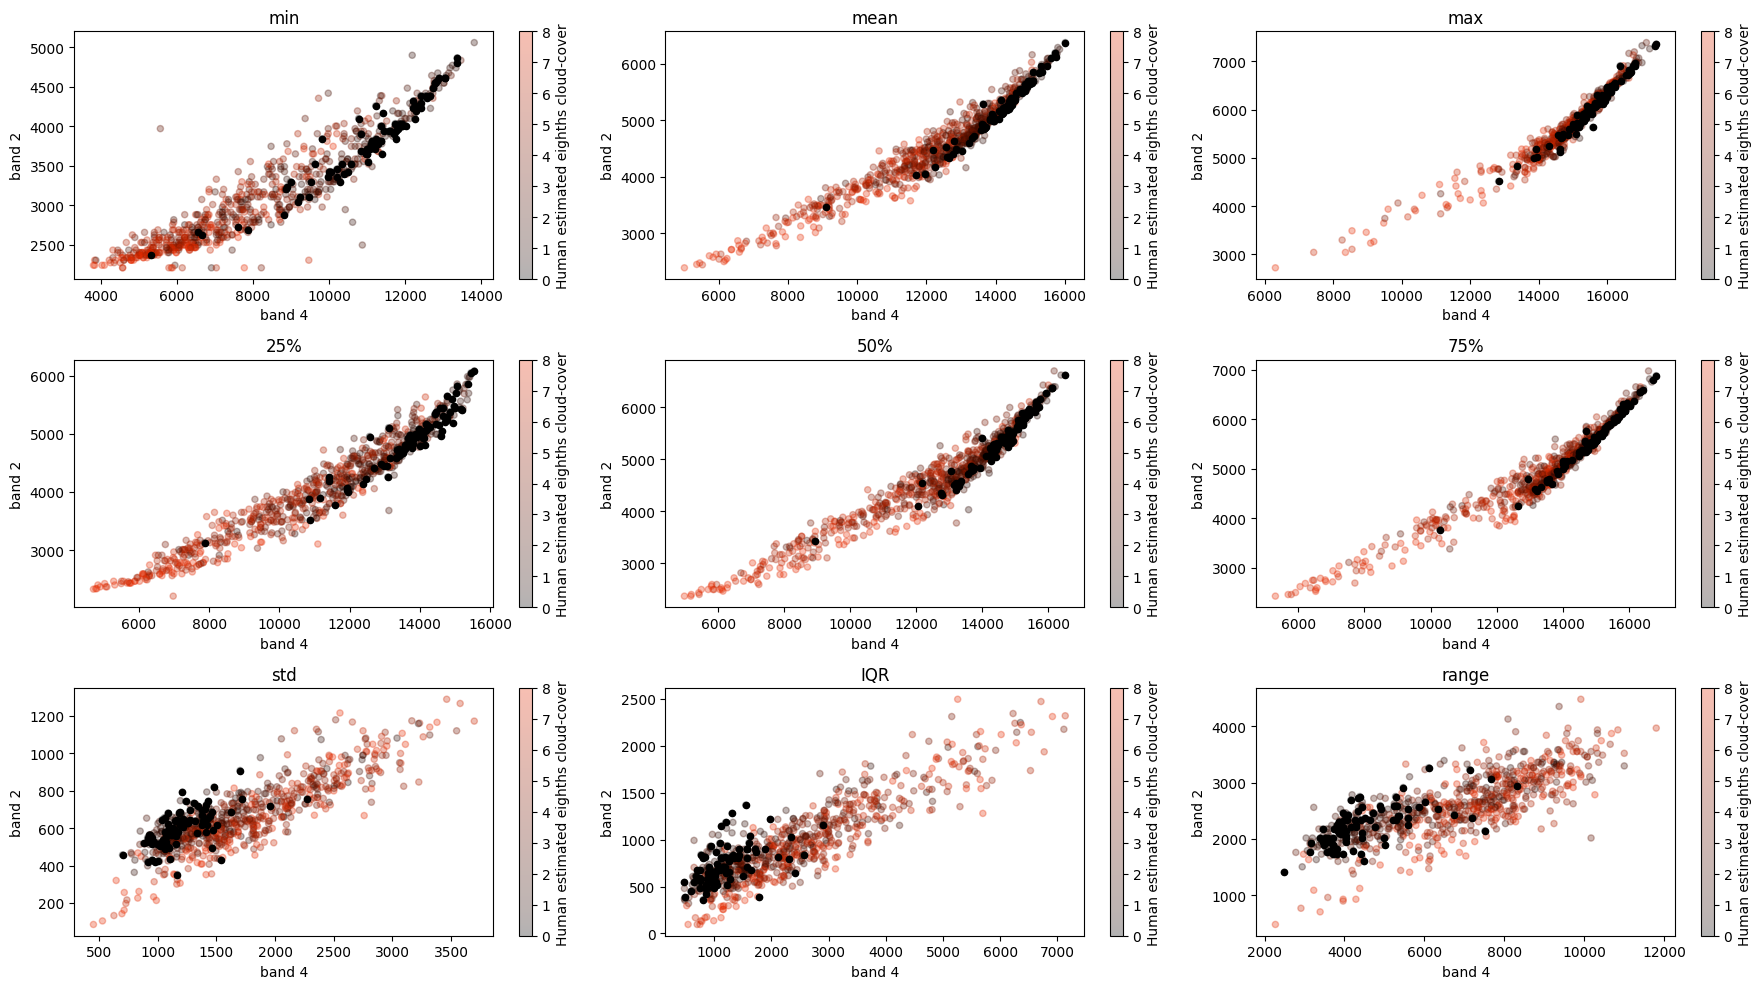

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
clear = multiband_stats[("human", "clouds")] == 0
for stat_name, ax in zip(gc.STAT_NAMES, axes.flatten()):
    gc.plot_band_comparison(multiband_stats, stat_name, ax, 4, 2, clear_mask=clear)
fig.tight_layout()

## Band-2-corrected estimator

Fit a per-pixel clear-sky relation of band 4 against band 2, and use it
to correct band-4 brightness for each pixel's own clear-sky baseline.

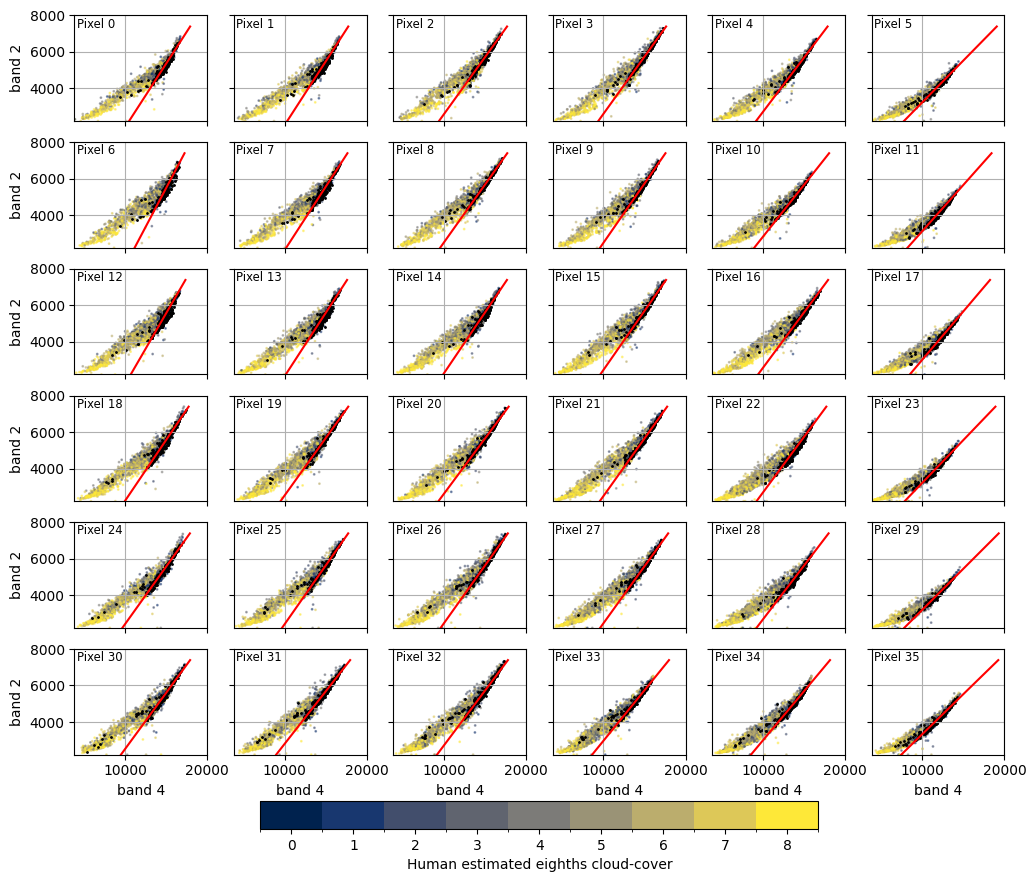

In [13]:
models    = gc.fit_clear_sky_model(multiband, x_band=2, y_band=4, per_pixel=True)
corrected = gc.apply_clear_sky_correction(multiband, models, x_band=2, y_band=4)
fig = gc.plot_per_pixel_models(corrected, models, x_band=4, y_band=2)
fig.savefig('clear_band2_vs_band4_by_pixel.png')
None

In [14]:
norm_samples = gc.as_value_frame(corrected, ('4corr', 'value'))

Verify that ou distribution of samples is what we expect

Text(0, 0.5, 'number of quarters')

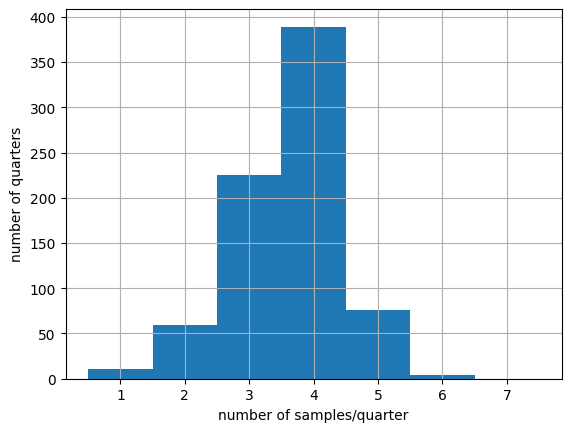

In [15]:
ax = (norm_samples
    .loc[0, :]
    .groupby(['year', 'month', 'sday', 'quarter'])
    .count()['clouds']
    .hist(bins=np.arange(0, 8)+0.5)
)
ax.set_xlabel('number of samples/quarter')
ax.set_ylabel('number of quarters')

Text(0.5, 0, 'cloud level')

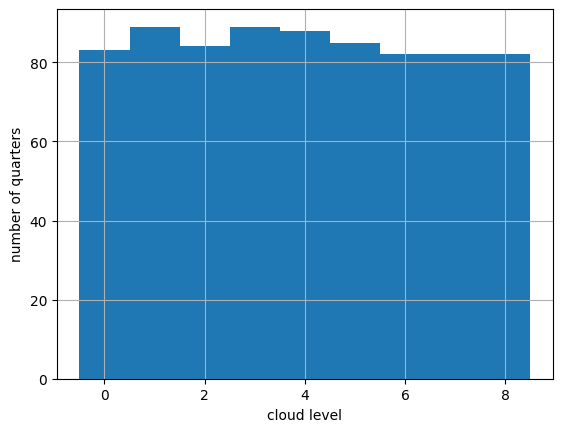

In [16]:
ax = (norm_samples
    .groupby(['year', 'month', 'sday', 'quarter'])
    .first()
    .clouds
    .hist(bins=np.arange(0, 10)-0.5)
)
ax.set_ylabel("number of quarters")
ax.set_xlabel("cloud level")

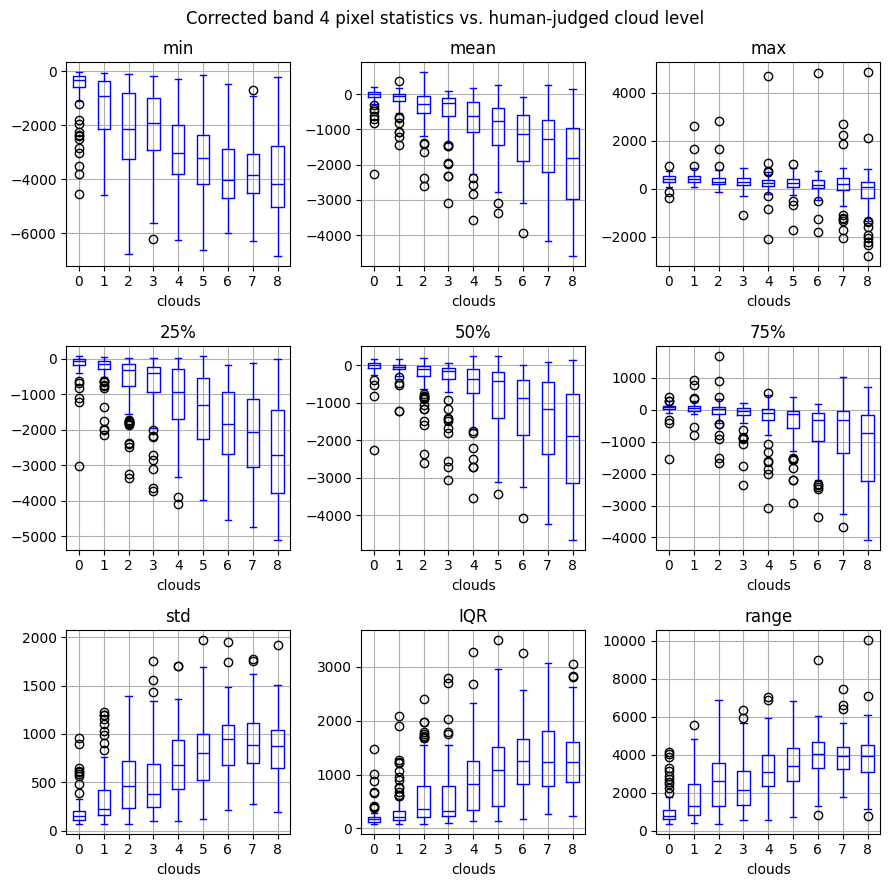

In [17]:
stats        = gc.compute_sample_stats(norm_samples, value_column='value')
_ = gc.plot_sample_stats(stats, title="Corrected band 4 pixel statistics vs. human-judged cloud level")

In [18]:
candidates = np.sort(norm_samples['value'].dropna().unique())
candidates = candidates[candidates < 0]
candidates = candidates[candidates > norm_samples.loc[norm_samples.clouds == 5, 'value'].median()]

In [19]:
%%time
#norm_samples  = gc.as_value_frame(corrected, ("4corr", "value"))
#norm_cloudcut = gc.reference_quantile(norm_samples, "value")
candidates = np.sort(norm_samples.value.dropna().astype(int).unique())
norm_cloudcut = gc.optimize_cloudcut_obs(norm_samples, "value", candidates=candidates)
norm_by_q     = gc.compute_by_quarter(norm_samples, "value", norm_cloudcut)

CPU times: user 2min 51s, sys: 715 ms, total: 2min 52s
Wall time: 2min 54s


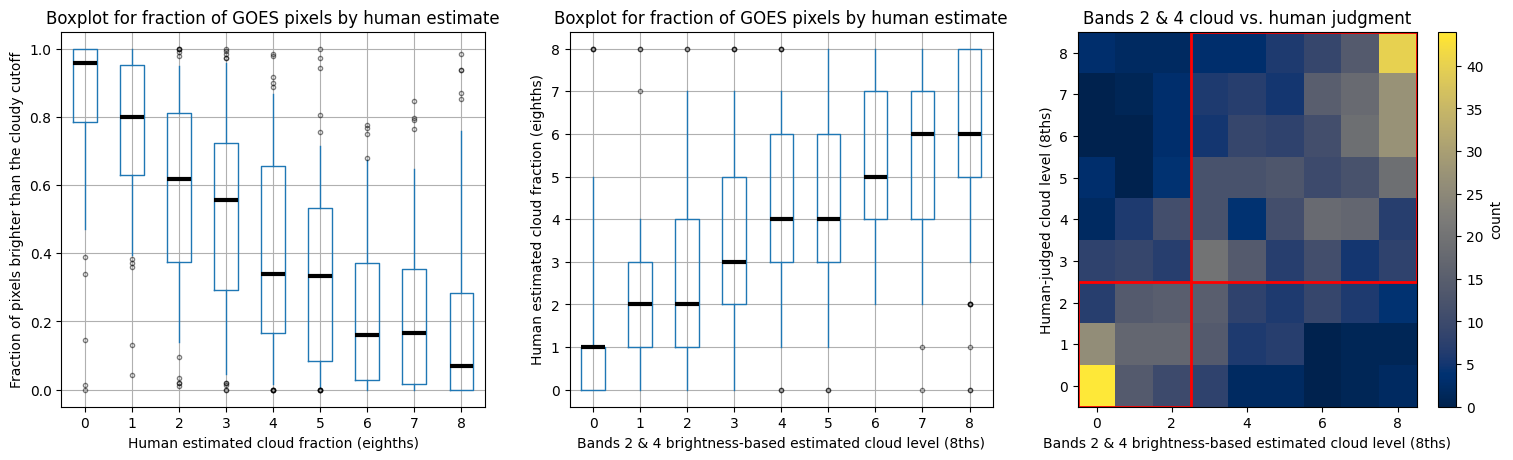

In [20]:
fig = gc.plot_norm_by_quarter(norm_by_q)
fig.savefig('pred_by_quarter.png')

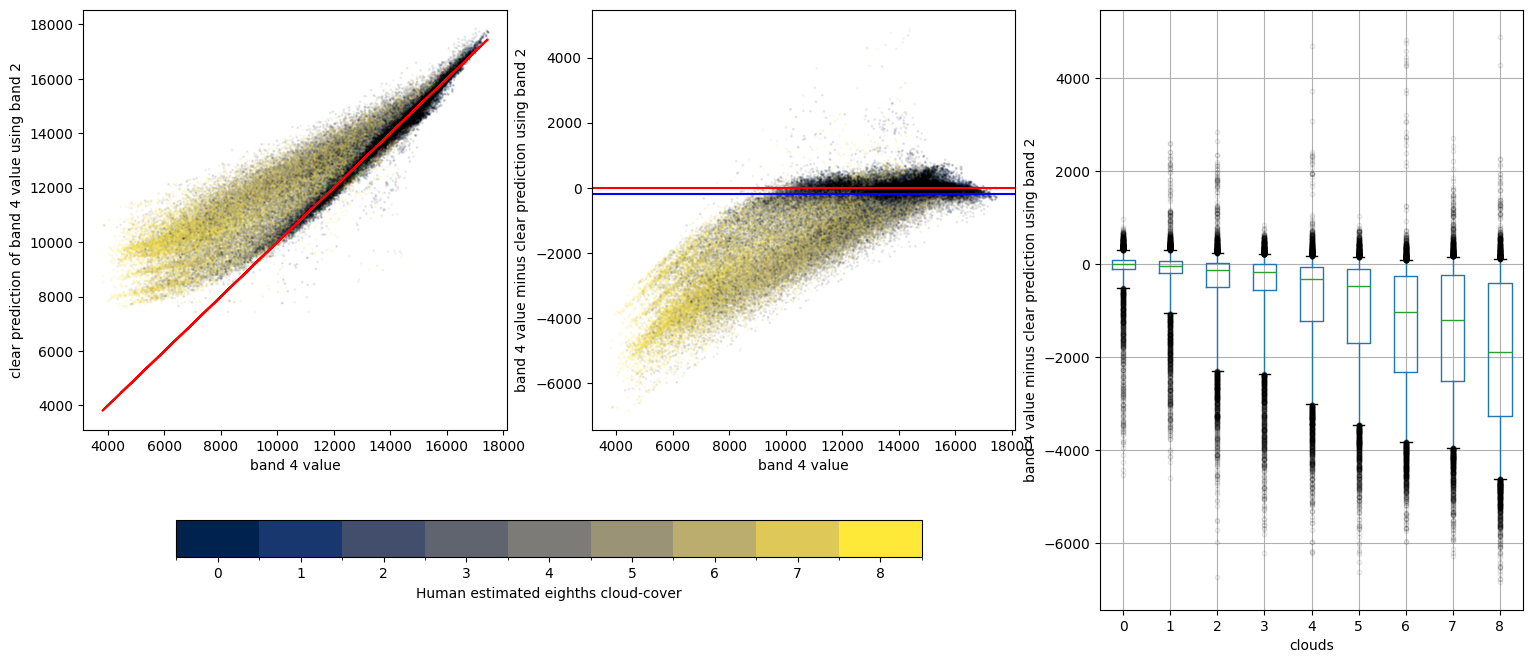

In [21]:
fig = gc.plot_clear_sky_model(corrected, "value", x_band=2, y_band=4, cloudcut=norm_cloudcut)
fig.savefig('clear_sky_model.png')
None

## Comparing estimators

Per-band brightness cuts vs. the band-2-corrected cut, scored against
the human quarter reports.

In [22]:
by_quarter_per_band = {}
b_cloudcut = {}
for b in (2, 4, 6):
    b_samples = gc.as_value_frame(multiband, (b, "value"))
    b_cloudcut[b] = gc.optimize_cloudcut_obs(b_samples, "value")
    by_quarter_per_band[b] = gc.compute_by_quarter(b_samples, "value", b_cloudcut[b])

match_stats = gc.compare_estimates(multiband, {
    "cut on 2": by_quarter_per_band[2],
    "cut on 4": by_quarter_per_band[4],
    "cut on 6": by_quarter_per_band[6],
    "cut on 4 corrected by 2": norm_by_q,
})
for b in (2, 4, 6):
    match_stats.loc[f"cut on {b}", 'cloudcut'] = b_cloudcut[b]

match_stats.loc["cut on 4 corrected by 2", 'cloudcut'] = norm_cloudcut
match_stats

,n,n_exact,n_match_obs,human_mean_eighths,estimated_mean_eighths,frac_match_obs,cloudcut
cut on 2,764.0,161.0,571.0,3.956806,4.739529,0.747382,4864.0
cut on 4,764.0,162.0,586.0,3.956806,4.379581,0.767016,13312.0
cut on 6,764.0,175.0,592.0,3.956806,4.345550,0.774869,15424.0
cut on 4 corrected by 2,764.0,182.0,608.0,3.956806,4.327225,0.795812,-195.0


## Missing quarters, corrected

Apply the calibration-sample models to the 2015
quarters with a missing human report -- the models and `norm_cloudcut` come
from calibration; only the eighths come from the missing-quarter data.

PosixPath('satellite_clouds_4corr2_2015.txt')

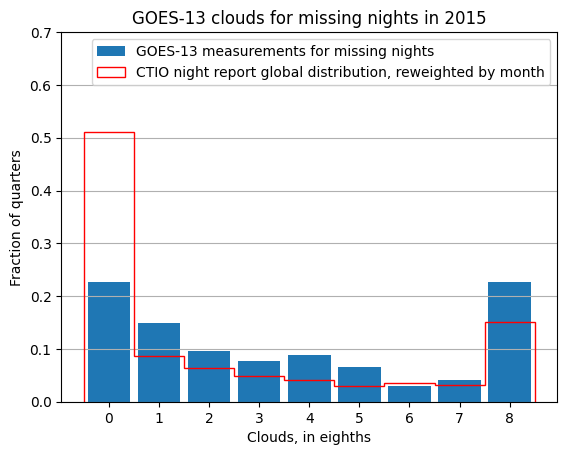

In [23]:
missing_multiband = gc.load_multiband_samples(missing_quarters, bands=(2, 4))
missing_corrected = gc.apply_clear_sky_correction(missing_multiband, models, x_band=2, y_band=4)
missing_norm      = gc.compute_by_quarter(
    gc.as_value_frame(missing_corrected, ("4corr", "value")), "value", norm_cloudcut,
)
fig = gc.plot_estimate_histogram(
    missing_norm,
    quarter_reports=quarter_reports,
    title="GOES-13 clouds for missing nights in 2015"
)
fig.savefig("missing2015dist.png")
gc.write_band_estimates(
    missing_norm,
    "satellite_clouds_4corr2_2015.txt",
    columns=["year", "month", "sday", "quarter", "estimated_eighths", "fraction_above_cloudcut"]
)


## Save estimates

In [24]:
window_size = gc.DEFAULT_WINDOW_SIZE
hdf5_key = f'window{window_size}'
norm_by_q.to_hdf('fit_quarters.h5', key=hdf5_key)
missing_norm.to_hdf('missing_2015.h5', key=hdf5_key) 

### Compare sample estimates

In [25]:
nbqs = []
for w in (4, 6, 8, 10):
    try:
        this_nbq = pd.read_hdf('fit_quarters.h5', key=f'window{w}')
        this_nbq.columns = pd.MultiIndex.from_product([[w], this_nbq.columns])
        this_nbq.columns.names = ['window', 'value']
        nbqs.append(this_nbq)
    except:
        pass

nbq = pd.concat(nbqs, axis='columns')

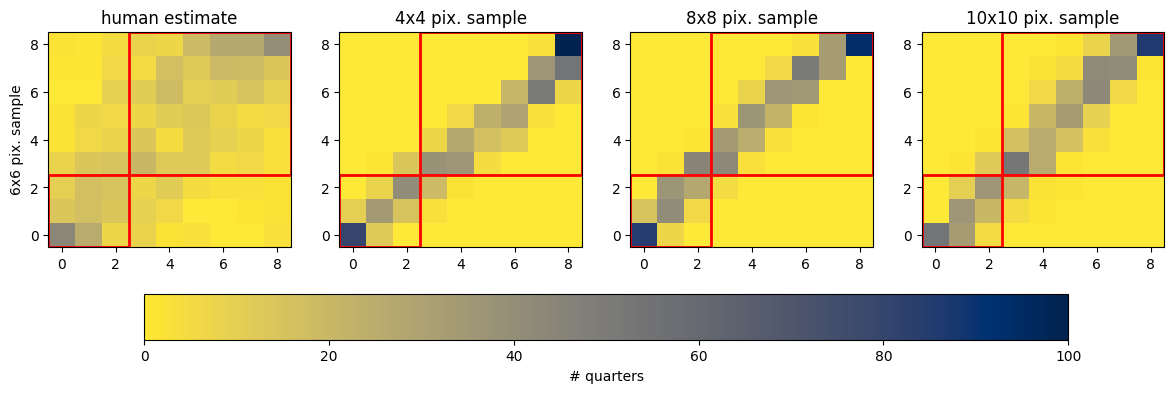

In [26]:
fig = gc.plot_window_comparison(nbq, window_size=window_size, include_human=True)
fig.savefig('compare_windows.png')

### Compare 2015 missing data

In [27]:
mqs_2015 = []
for w in (4, 6, 8, 10):
    try:
        this_mq = pd.read_hdf('missing_2015.h5', key=f'window{w}')
        this_mq.columns = pd.MultiIndex.from_product([[w], this_mq.columns])
        this_mq.columns.names = ['window', 'value']
        mqs_2015.append(this_mq)
    except:
        pass

mq2015 = pd.concat(mqs_2015, axis='columns')

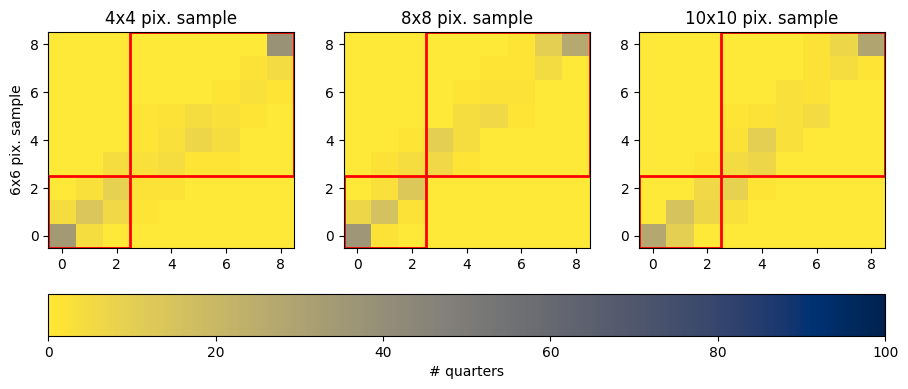

In [28]:
fig = gc.plot_window_comparison(mq2015, window_size=window_size, include_human=False)
fig.savefig('compare_2015_windows.png')

## Load and GOES-13 data for years with missing CTIO data

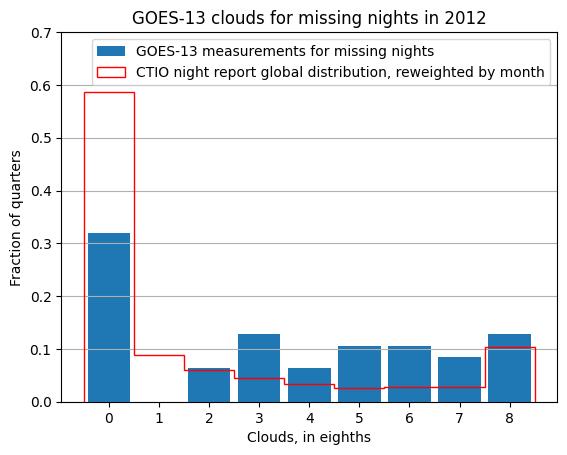

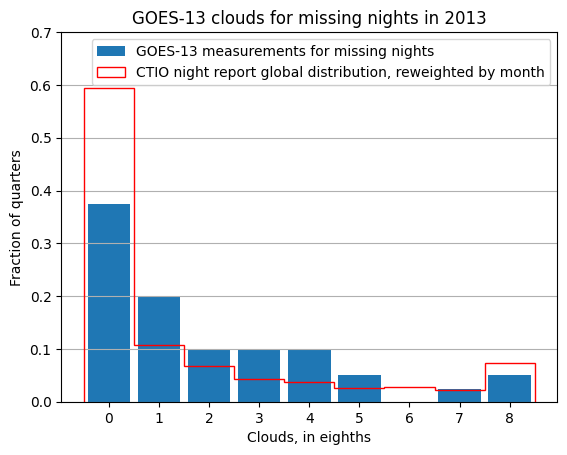

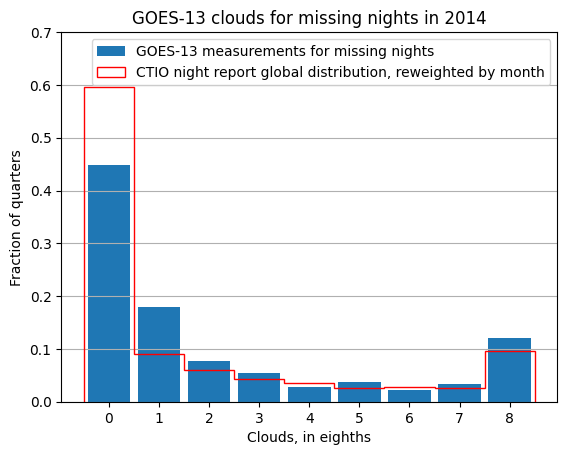

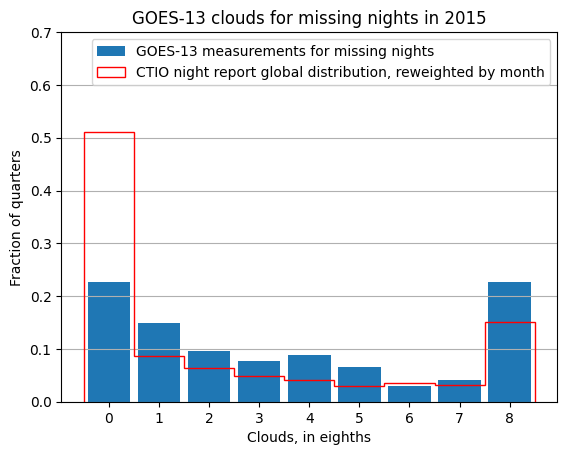

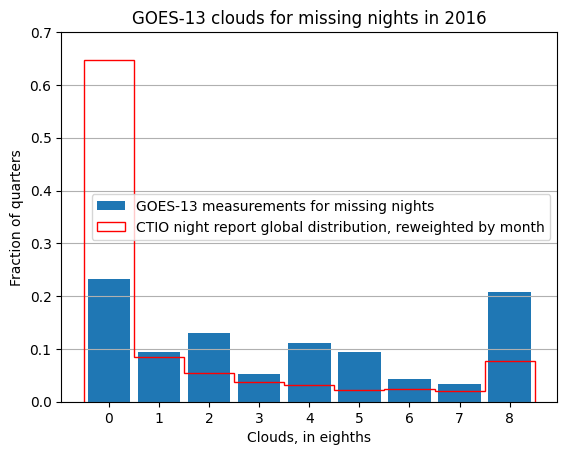

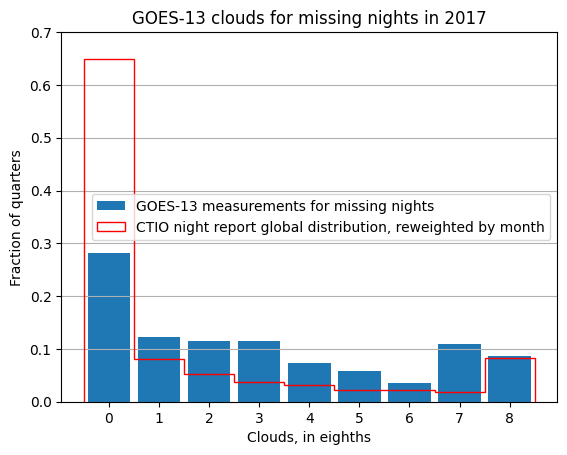

In [29]:
def missing_goes_key(year, band, window_size=gc.DEFAULT_WINDOW_SIZE):
    return f'missing_{year}_band_{band}_window_{window_size}'

def process_missing_year(quarter_reports, year):
    missing_quarters = gc.select_missing_quarters(quarter_reports, year=year)
    missing_multiband = gc.load_multiband_samples(missing_quarters, bands=(2, 4))
    missing_corrected = gc.apply_clear_sky_correction(missing_multiband, models, x_band=2, y_band=4)
    missing_norm      = gc.compute_by_quarter(
        gc.as_value_frame(missing_corrected, ("4corr", "value")), "value", norm_cloudcut,
    )

    window_size = gc.DEFAULT_WINDOW_SIZE
    hdf5_key = f'window{window_size}'
    missing_norm.to_hdf(f'missing_{year}.h5', key=hdf5_key) 
    gc.write_band_estimates(
        missing_norm,
        f"satellite_clouds_4corr2_{year}.txt",
        columns=["year", "month", "sday", "quarter", "estimated_eighths", "fraction_above_cloudcut"]
    )
    
    fig = gc.plot_estimate_histogram(
        missing_norm,
        quarter_reports=quarter_reports,
        title=f"GOES-13 clouds for missing nights in {year}"
    )
    fig.savefig(f"missing{year}dist.png")
    gc.write_band_estimates(
        missing_norm,
        f"satellite_clouds_4corr2_{year}.txt",
        columns=["year", "month", "sday", "quarter", "estimated_eighths", "fraction_above_cloudcut"]
    )

    return missing_norm

for year in np.arange(2012, 2018):
    process_missing_year(quarter_reports, year)

In [30]:
!pwd

/home/aidevel/aisandbox/rubin_sim_notebooks/clouds
